<a href="https://colab.research.google.com/github/ismaelpereziimas/Procesamiento-de-Imagenes-Medicas/blob/main/Notebooks/2026_Procesamiento_de_Imagenes_Medicas_MLP_Feature_Selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Procesamiento de imágenes médicas**
----------

# Programación de redes neuronales (MLP) con seleccion de características
-------

Por: Ing. Ismael Pérez Ruiz



Se utilizará el dataset de clasificación de flores Iris, por medio de la importación propuesta en: https://www.kaggle.com/code/nandaprasetia/dataset-iris

El dataset Iris es considerado el equivalente al clásico "Hola Mundo" en el ámbito del Machine Learning (Aprendizaje Automático) y la Inteligencia Artificial. Es uno de los conjuntos de datos más famosos, antiguos y utilizados para la enseñanza y prueba de algoritmos de clasificación.

Fue creado en 1936 por el estadístico y biólogo británico Ronald Fisher.



**¿Qué contiene el dataset?**

El conjunto de datos es bastante pequeño y sencillo. Contiene un total de 150 registros (muestras) de flores de la planta Iris, divididas equitativamente en 3 especies diferentes (50 muestras por especie):


*   Iris setosa
*   Iris versicolor
*   Iris virginica



**Las Características (Features)**

Por cada una de las 150 flores, el dataset incluye 4 variables numéricas o atributos, medidos en centímetros:

* Largo del sépalo

* Ancho del sépalo

* Largo del pétalo

* Ancho del pétalo

El objetivo principal al usar este dataset en IA es entrenar un modelo supervisado que aprenda a relacionar estas 4 mediciones físicas para predecir a qué especie pertenece una flor específica.

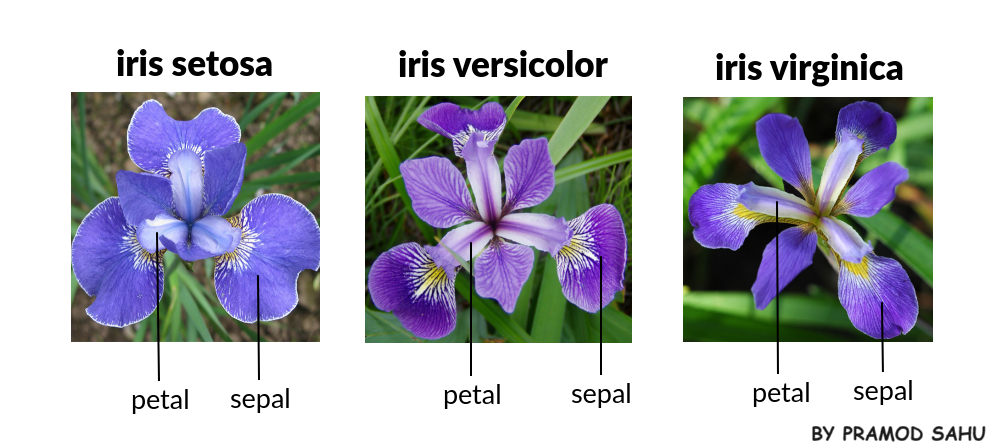






# Importación de las librerías y el dataset

En este paso importaremos las librerías necesarias para la graficación, trabajo con DataFrames, carga del dataset, métricas, generaci+on de redes neuronales, etc.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Tensorflow nos ayudará con la contruccion de la red neuronal.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

#Sklearn nos ayudará para importar el dataset, y utilizar herramientas como
#datasets, métricas, estandarización, división del dataset, etc.
from sklearn import datasets
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical




In [6]:
#Cargamos el dataset de iris, desde Sklearn
iris=datasets.load_iris()

In [7]:
#Mostramos el dataset
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [8]:
# Membuat DataFrame dari dataset Iris
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names) #se convierte el dataset a dataframe de pandas

# Menambahkan kolom target (jenis bunga) ke DataFrame
iris_df['target'] = iris.target  #se extrae la etiqueta target

# Menambahkan kolom target_names (nama jenis bunga) ke DataFrame
iris_df['target_names'] = [iris.target_names[i] for i in iris.target] #se agrega la columna "target names" a cada una de las filas para identificar el nombre de la especie

# Análisis exploratorio de los datos
En esta etapa se visualizan los datos de diferentes formas para ver las relaciones que tienen entre sí, así como diferentes métricas.

En esta ocasión, solo se mostrará la tabla con los valores obtenidos y posteriormente se graficará la distribución de los por característica y clase. También se graficará la clasificación por cada par de características.

In [9]:
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_names
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


<Figure size 1000x600 with 0 Axes>

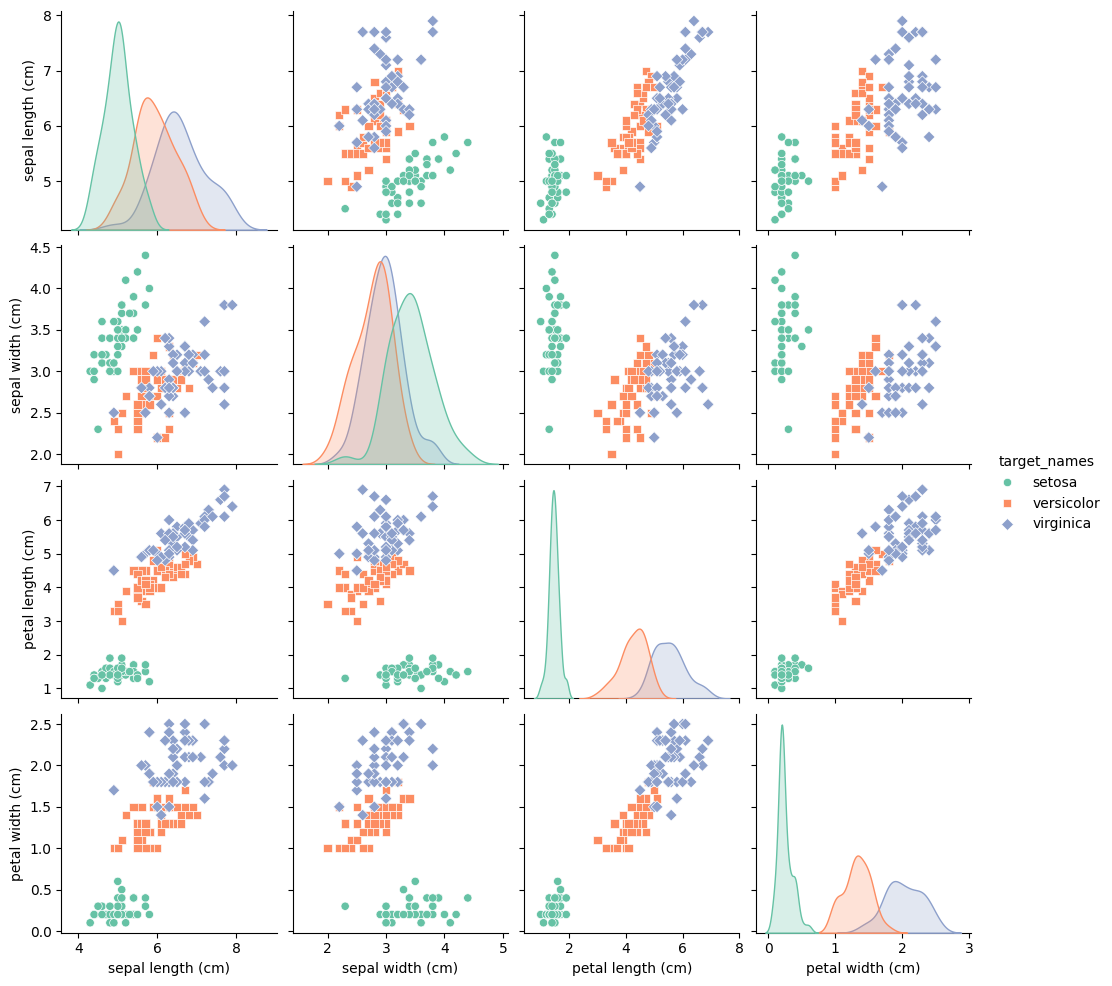

In [10]:
#se grafica la distribución del dataset y se comparan dos características.
#se hace de esta forma ya que no es posible mostrar una grafica de 4 características.
plt.figure(figsize=(10, 6))
sns.pairplot(iris_df.drop('target',axis=1), hue='target_names', palette='Set2', markers=["o", "s", "D"])
plt.show()

# Preprocesamiento de los datos
En esta etapa, los datos se adecuan para poder procesarlos con una red neuronal.

*  Se prepara el conjunto de datos de prueba eliminando las columnas que no son de características.

* El conjunto de respuestas correctas de la red tambien se prepara aislándolo de las tablas.

* Se realiza la división del dataset en entrenamiento (80%) y prueba (20%)
* Se reescalan los datos para que sean de la misma magnitud, utilizando la técnica de estandarización. Para más información, visitar: https://www.youtube.com/watch?v=bqhQ2LWBheQ

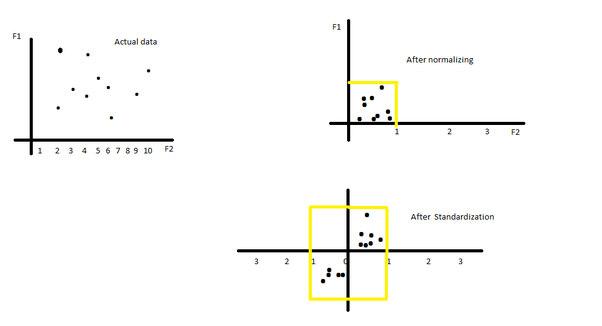

In [104]:
#se separan las características de las etiquetas correctas,
#x contiene las características
#y contiene los valores verdaderos.
x=iris_df[['petal width (cm)','petal length (cm)']].values
y=iris_df['target'].values

In [105]:
print(x)

[[0.2 1.4]
 [0.2 1.4]
 [0.2 1.3]
 [0.2 1.5]
 [0.2 1.4]
 [0.4 1.7]
 [0.3 1.4]
 [0.2 1.5]
 [0.2 1.4]
 [0.1 1.5]
 [0.2 1.5]
 [0.2 1.6]
 [0.1 1.4]
 [0.1 1.1]
 [0.2 1.2]
 [0.4 1.5]
 [0.4 1.3]
 [0.3 1.4]
 [0.3 1.7]
 [0.3 1.5]
 [0.2 1.7]
 [0.4 1.5]
 [0.2 1. ]
 [0.5 1.7]
 [0.2 1.9]
 [0.2 1.6]
 [0.4 1.6]
 [0.2 1.5]
 [0.2 1.4]
 [0.2 1.6]
 [0.2 1.6]
 [0.4 1.5]
 [0.1 1.5]
 [0.2 1.4]
 [0.2 1.5]
 [0.2 1.2]
 [0.2 1.3]
 [0.1 1.4]
 [0.2 1.3]
 [0.2 1.5]
 [0.3 1.3]
 [0.3 1.3]
 [0.2 1.3]
 [0.6 1.6]
 [0.4 1.9]
 [0.3 1.4]
 [0.2 1.6]
 [0.2 1.4]
 [0.2 1.5]
 [0.2 1.4]
 [1.4 4.7]
 [1.5 4.5]
 [1.5 4.9]
 [1.3 4. ]
 [1.5 4.6]
 [1.3 4.5]
 [1.6 4.7]
 [1.  3.3]
 [1.3 4.6]
 [1.4 3.9]
 [1.  3.5]
 [1.5 4.2]
 [1.  4. ]
 [1.4 4.7]
 [1.3 3.6]
 [1.4 4.4]
 [1.5 4.5]
 [1.  4.1]
 [1.5 4.5]
 [1.1 3.9]
 [1.8 4.8]
 [1.3 4. ]
 [1.5 4.9]
 [1.2 4.7]
 [1.3 4.3]
 [1.4 4.4]
 [1.4 4.8]
 [1.7 5. ]
 [1.5 4.5]
 [1.  3.5]
 [1.1 3.8]
 [1.  3.7]
 [1.2 3.9]
 [1.6 5.1]
 [1.5 4.5]
 [1.6 4.5]
 [1.5 4.7]
 [1.3 4.4]
 [1.3 4.1]
 [1.3 4. ]
 [1.2 4.4]

In [106]:
print(y)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [107]:
#se convierte a forma categórica.
#esta forma es la que nos conviene usar, imagina que son 3 percetrones de salida y cada uno clasifica una especie.
y_categorical=to_categorical(y)

In [108]:
print(y_categorical)

[[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0.

In [109]:
#se divide el datase entre entrenamiento y prueba
#80% entrenamiento, 20% prueba.
X_train,X_test,y_train,y_test=train_test_split(x,y_categorical,test_size=0.2,random_state=42)

In [110]:
#Se utiliza la estandarización para dejar todos los valores en un mismo rango.
scaler=StandardScaler()

In [111]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [112]:
print(X_train)

[[-1.31260282 -1.56253475]
 [-1.04563275 -1.27600637]
 [ 0.28921757  0.38585821]
 [-1.31260282 -1.2187007 ]
 [-1.31260282 -1.39061772]
 [ 0.95664273  0.72969227]
 [ 0.4227026   0.44316389]
 [-1.31260282 -1.27600637]
 [-1.31260282 -1.33331205]
 [-1.44608785 -1.27600637]
 [ 0.95664273  0.78699794]
 [ 0.55618763  0.44316389]
 [ 0.4227026   0.55777524]
 [-1.04563275 -1.39061772]
 [-1.31260282 -1.27600637]
 [-0.24472256 -0.01528151]
 [ 0.4227026   0.78699794]
 [ 0.8231577   1.01622064]
 [ 0.28921757  0.38585821]
 [ 1.75755292  1.3600547 ]
 [ 0.15573254  0.27124686]
 [ 1.22361279  1.64658307]
 [ 0.4227026   0.44316389]
 [-1.31260282 -1.33331205]
 [ 1.09012776  1.70388875]
 [-0.24472256  0.21394119]
 [-1.31260282 -1.33331205]
 [-1.17911778 -1.39061772]
 [-1.04563275 -1.04678367]
 [-0.24472256 -0.12989286]
 [ 0.8231577   0.67238659]
 [-1.31260282 -1.04678367]
 [-1.31260282 -1.2187007 ]
 [-0.91214772 -1.16139502]
 [ 0.15573254  0.27124686]
 [-1.31260282 -1.27600637]
 [ 0.02224751  0.27124686]
 

# Construcción de la red neuronal.

En esta sección se construirá y entrenará el modelo de red neuronal.

In [113]:
#Se crea el MLP
model= Sequential([

  Dense(4, input_shape=(2,), activation='relu', name='Capa_entrada'),
  Dense(10, activation='relu', name='Capa_oculta_1'),
  Dense(3, activation='softmax', name='Capa_salida')
])

#Configuración estándar: optimizador adam, función de pérdida: entropía cruzada, la métrica que se usará para la prueba es el accuracy
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [122]:
#Descripción del modelo que se acaba de crear.
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Capa_entrada (Dense)            │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_oculta_1 (Dense)           │ (None, 10)             │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_salida (Dense)             │ (None, 3)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 287 (1.12 KB)

 Trainable params: 95 (380.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 192 (772.00 B)

In [123]:
#Entrenamiento del modelo.
#Configuración inicial de 20 épocas, con un batch size de 8 elementos,
#se separa un 10% del dataset de entrenamiento para validación.
#verbose es para mostrar la barra de progreso.
history=model.fit(X_train,y_train,epochs=30,batch_size=8,validation_split=0.1,verbose=1)

Epoch 1/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6852 - loss: 0.5133 - val_accuracy: 0.5833 - val_loss: 0.6054
Epoch 2/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7130 - loss: 0.4993 - val_accuracy: 0.5833 - val_loss: 0.5899
Epoch 3/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7222 - loss: 0.4861 - val_accuracy: 0.5833 - val_loss: 0.5736
Epoch 4/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7222 - loss: 0.4738 - val_accuracy: 0.5833 - val_loss: 0.5586
Epoch 5/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7222 - loss: 0.4621 - val_accuracy: 0.6667 - val_loss: 0.5454
Epoch 6/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7407 - loss: 0.4513 - val_accuracy: 0.7500 - val_loss: 0.5321
Epoch 7/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7500 - loss: 0.4415 - val_accuracy: 0.7500 - val_loss: 0.5190
Epoch 8/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7685 - loss: 0.4317 - val_accuracy: 0.8333 - val_l

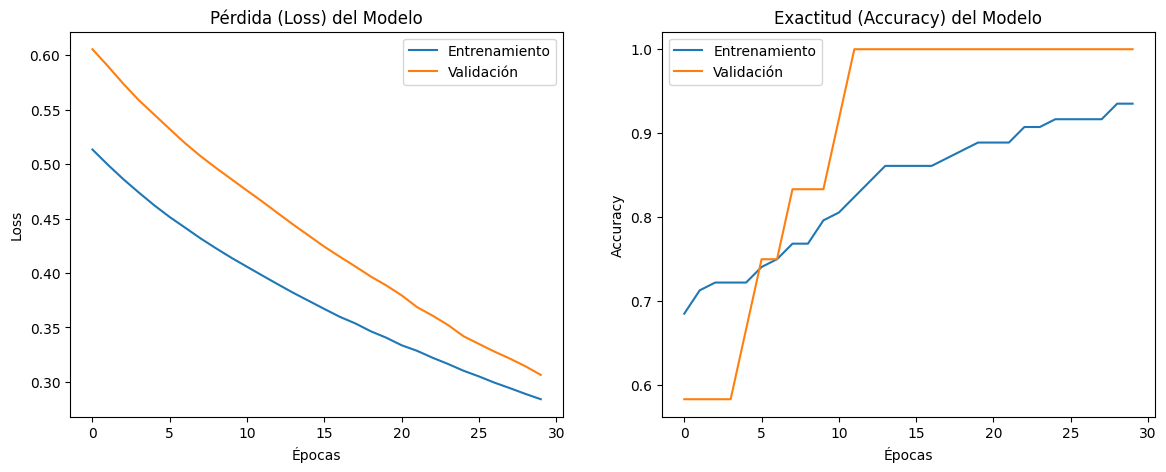

In [124]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica de Loss
ax1.plot(history.history['loss'], label='Entrenamiento')
ax1.plot(history.history['val_loss'], label='Validación')
ax1.set_title('Pérdida (Loss) del Modelo')
ax1.set_xlabel('Épocas')
ax1.set_ylabel('Loss')
ax1.legend()

# Gráfica de Accuracy
ax2.plot(history.history['accuracy'], label='Entrenamiento')
ax2.plot(history.history['val_accuracy'], label='Validación')
ax2.set_title('Exactitud (Accuracy) del Modelo')
ax2.set_xlabel('Épocas')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.show()

# Evaluación del modelo
Esta evaluación se realiza con el conjunto de prueba.

In [125]:
loss,accuracy=model.evaluate(X_test,y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9667 - loss: 0.2238


In [126]:
clasificacion=model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


In [127]:
y_pred=np.argmax(clasificacion,axis=1)
y_true=np.argmax(y_test,axis=1)

In [128]:
matriz=confusion_matrix(y_true,y_pred)

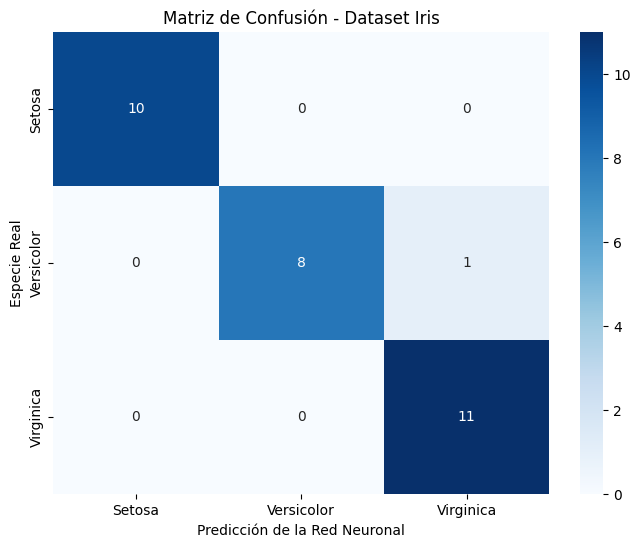

In [129]:
plt.figure(figsize=(8, 6))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Setosa', 'Versicolor', 'Virginica'],
            yticklabels=['Setosa', 'Versicolor', 'Virginica'])

plt.title('Matriz de Confusión - Dataset Iris')
plt.xlabel('Predicción de la Red Neuronal')
plt.ylabel('Especie Real')
plt.show()